In [9]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [10]:
# --- Snippet 1: EfficientNet feature backbone (for fusion) ---
import torch
import torch.nn as nn
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class EfficientNetBackbone(nn.Module):
    def __init__(self, model_name="tf_efficientnet_b3_ns", pretrained=True, emb_dim=512, freeze_backbone=False):
        super().__init__()
        # create timm model but without classifier head
        # using num_classes=0 makes timm return feature vectors (num_features) in many models
        try:
            self.net = timm.create_model(model_name, pretrained=pretrained, num_classes=0, global_pool='avg')
            in_features = self.net.num_features
        except Exception:
            # fallback: create with classifier then remove it
            tmp = timm.create_model(model_name, pretrained=pretrained, num_classes=2)
            # try common attribute names for the head
            if hasattr(tmp, "classifier"):
                in_features = tmp.classifier.in_features if hasattr(tmp.classifier, "in_features") else tmp.num_features
                tmp.classifier = nn.Identity()
            elif hasattr(tmp, "fc"):
                in_features = tmp.fc.in_features
                tmp.fc = nn.Identity()
            else:
                # last resort: use tmp.num_features if present
                in_features = getattr(tmp, "num_features", 1280)
            self.net = tmp

        # optional freeze
        if freeze_backbone:
            for p in self.net.parameters():
                p.requires_grad = False

        # projection to fixed embedding size
        self.proj = nn.Sequential(
            nn.Linear(in_features, emb_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

    def forward(self, x):
        # x: tensor (B,3,224,224)
        # many timm models with num_classes=0 return a feature vector already when called
        feats = None
        try:
            feats = self.net(x)                # if net configured with num_classes=0 -> returns (B, num_features)
            # if net returned (B, C, H, W), try global pooling
            if feats.ndim == 4:
                feats = feats.mean(dim=[2,3])  # global avg pool as fallback
        except Exception:
            # fallback: forward through features / features extractor if available
            if hasattr(self.net, "forward_features"):
                feats = self.net.forward_features(x)
                if feats.ndim == 4:
                    feats = feats.mean(dim=[2,3])
            else:
                # last resort: run net and try to flatten
                out = self.net(x)
                if out.ndim == 4:
                    feats = out.mean(dim=[2,3])
                else:
                    feats = out

        emb = self.proj(feats)
        return emb

# quick test: create backbone and run a dummy batch
backbone = EfficientNetBackbone(model_name="tf_efficientnet_b3_ns", pretrained=True, emb_dim=512, freeze_backbone=False)
backbone = backbone.to(device)
print("Backbone ready")

# dummy batch (random) - shape (B,3,224,224)
B = 4
x = torch.randn(B,3,224,224).to(device)
with torch.no_grad():
    embs = backbone(x)
print("Embedding shape:", embs.shape)   # expect (B, 512)


Device: cuda
Backbone ready
Embedding shape: torch.Size([4, 512])


In [11]:
# --- Snippet 2: ViT feature backbone (for fusion) ---
import torch
import torch.nn as nn
import timm
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class ViTBackbone(nn.Module):
    def __init__(self, model_name="vit_base_patch16_224", pretrained=True, emb_dim=512, freeze_backbone=False, load_weights=False, weights_path=None):
        super().__init__()
        # create timm ViT model; prefer num_classes=0 / global_pool='avg' when available
        try:
            self.net = timm.create_model(model_name, pretrained=pretrained, num_classes=0, global_pool='avg')
            in_features = self.net.num_features
        except Exception:
            tmp = timm.create_model(model_name, pretrained=pretrained, num_classes=2)
            # handle common head names
            if hasattr(tmp, "head"):
                in_features = tmp.head.in_features if hasattr(tmp.head, "in_features") else getattr(tmp, "num_features", 768)
                tmp.head = nn.Identity()
            elif hasattr(tmp, "heads"):
                in_features = tmp.heads.head.in_features if hasattr(tmp.heads, "head") else getattr(tmp, "num_features", 768)
                tmp.heads = nn.Identity()
            else:
                in_features = getattr(tmp, "num_features", 768)
            self.net = tmp

        # optional freeze
        if freeze_backbone:
            for p in self.net.parameters():
                p.requires_grad = False

        # projection to fixed embedding size
        self.proj = nn.Sequential(
            nn.Linear(in_features, emb_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # optionally load weights (your fine-tuned ViT)
        if load_weights and weights_path is not None and os.path.exists(weights_path):
            print("Loading ViT weights from:", weights_path)
            sd = torch.load(weights_path, map_location="cpu")
            # try to load into a normal timm ViT; allow missing keys (we removed head)
            self.net.load_state_dict(sd, strict=False)
            print("Loaded weights (strict=False).")

    def forward(self, x):
        # x: (B,3,224,224)
        feats = None
        try:
            feats = self.net(x)   # many timm ViT with num_classes=0 will return (B, features)
            # if (B,C,H,W) -> global pool
            if feats.ndim == 4:
                feats = feats.mean(dim=[2,3])
        except Exception:
            if hasattr(self.net, "forward_features"):
                feats = self.net.forward_features(x)
                if feats.ndim == 4:
                    feats = feats.mean(dim=[2,3])
            else:
                out = self.net(x)
                if out.ndim == 4:
                    feats = out.mean(dim=[2,3])
                else:
                    feats = out

        emb = self.proj(feats)
        return emb

# ---- Quick test (use your weights path if you want to load saved ViT) ----
weights_path = "/content/drive/MyDrive/morph_project/models/vit_hdf5.pth"  # change if needed
vit_backbone = ViTBackbone(model_name="vit_base_patch16_224", pretrained=False, emb_dim=512, freeze_backbone=False, load_weights=True, weights_path=weights_path)
vit_backbone = vit_backbone.to(device)
print("ViT backbone ready")

# dummy batch
B = 4
x = torch.randn(B,3,224,224).to(device)
with torch.no_grad():
    embs = vit_backbone(x)
print("Embedding shape:", embs.shape)   # expect (B, 512)


Device: cuda
Loading ViT weights from: /content/drive/MyDrive/morph_project/models/vit_hdf5.pth
Loaded weights (strict=False).
ViT backbone ready
Embedding shape: torch.Size([4, 512])


In [12]:
# --- REDEFINE H5Dataset before using it in fusion ---
import h5py
import torch
from torch.utils.data import Dataset

class H5Dataset(Dataset):
    def __init__(self, h5_path):
        self.h5 = h5py.File(h5_path, "r")
        self.X = self.h5["X"]     # (N, 224,224,3)
        self.y = self.h5["y"]     # (N,)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        img = self.X[idx]                   # already normalized floats
        label = self.y[idx]

        img = torch.tensor(img).permute(2,0,1)  # (C,H,W)
        label = torch.tensor(int(label), dtype=torch.long)
        return img, label


In [15]:
# --- SNIPPET 3: Fusion Model (EfficientNet + ViT) ---

import torch
import torch.nn as nn

# Use the backbones you created earlier:
# EfficientNetBackbone
# ViTBackbone
# H5Dataset (dataset loader for fusion)
# Make sure you already ran snippet 1 & 2 before this

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class FusionModel(nn.Module):
    def __init__(self,
                 eff_model,
                 vit_model,
                 emb_dim=512,
                 num_classes=2):
        super().__init__()

        self.eff = eff_model                         # EfficientNet backbone → (B, 512)
        self.vit = vit_model                         # ViT backbone → (B, 512)

        # classifier takes concatenated feature vector → (B, 1024)
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 2, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        eff_out = self.eff(x)       # (B, 512)
        vit_out = self.vit(x)       # (B, 512)

        fused = torch.cat([eff_out, vit_out], dim=1)    # (B, 1024)
        out = self.classifier(fused)                    # (B, 2)
        return out


# --- Instantiate backbones (must match snippets 1 & 2) ---

eff_backbone = EfficientNetBackbone(
    model_name="tf_efficientnet_b3_ns",
    pretrained=True,
    emb_dim=512,
    freeze_backbone=False
).to(device)

vit_backbone = ViTBackbone(
    model_name="vit_base_patch16_224",
    pretrained=False,
    emb_dim=512,
    freeze_backbone=False,
    load_weights=True,
    weights_path="/content/drive/MyDrive/morph_project/models/vit_hdf5.pth"
).to(device)


# --- Create Fusion Model ---
fusion_model = FusionModel(
    eff_model=eff_backbone,
    vit_model=vit_backbone,
    emb_dim=512,
    num_classes=2
).to(device)

print("Fusion model successfully created!")

# --- Dataset for fusion training (HDF5 normalized images) ---
train_ds = H5Dataset("/content/drive/MyDrive/morph_project/processed/train.h5")
test_ds  = H5Dataset("/content/drive/MyDrive/morph_project/processed/test.h5")

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
test_loader  = torch.utils.data.DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)


# --- Dummy forward test ---
x, y = next(iter(train_loader))
x = x.to(device)

with torch.no_grad():
    preds = fusion_model(x)

print("Dummy batch input:", x.shape)        # (B,3,224,224)
print("Fusion output:", preds.shape)        # (B,2)
print("Everything working!")


Device: cuda
Loading ViT weights from: /content/drive/MyDrive/morph_project/models/vit_hdf5.pth
Loaded weights (strict=False).
Fusion model successfully created!
Dummy batch input: torch.Size([32, 3, 224, 224])
Fusion output: torch.Size([32, 2])
Everything working!


/tmp/ipython-input-1718485012.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
  0%|          | 0/225 [00:00<?, ?it/s]/tmp/ipython-input-1718485012.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 225/225 [01:39<00:00,  2.25it/s]



Epoch 1/10
Train Loss: 0.2707 | Train Acc: 95.60%
Val   Loss: 0.5064 | Val   Acc: 82.64%
🔥 Saved best fusion model!


100%|██████████| 225/225 [01:42<00:00,  2.19it/s]



Epoch 2/10
Train Loss: 0.2646 | Train Acc: 95.92%
Val   Loss: 0.5049 | Val   Acc: 84.03%
🔥 Saved best fusion model!


100%|██████████| 225/225 [01:43<00:00,  2.17it/s]


...


Epoch 8/10
Train Loss: 0.2310 | Train Acc: 98.12%
Val   Loss: 0.5298 | Val   Acc: 84.80%


100%|██████████| 225/225 [01:39<00:00,  2.26it/s]



Epoch 9/10
Train Loss: 0.2304 | Train Acc: 98.13%
Val   Loss: 0.5104 | Val   Acc: 83.58%


100%|██████████| 225/225 [01:39<00:00,  2.27it/s]



Epoch 10/10
Train Loss: 0.2284 | Train Acc: 98.20%
Val   Loss: 0.5099 | Val   Acc: 83.97%


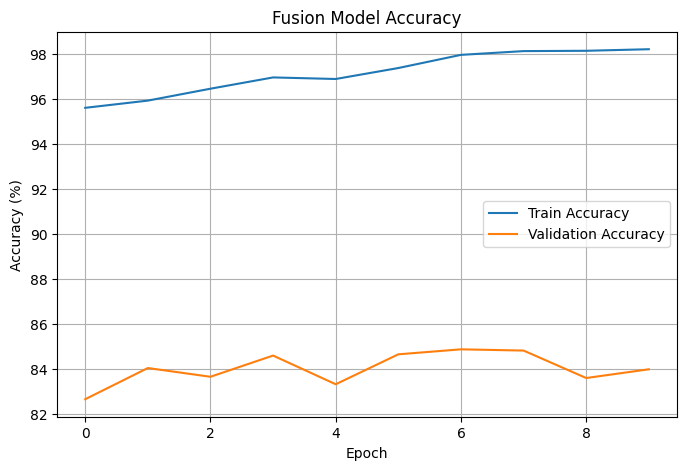

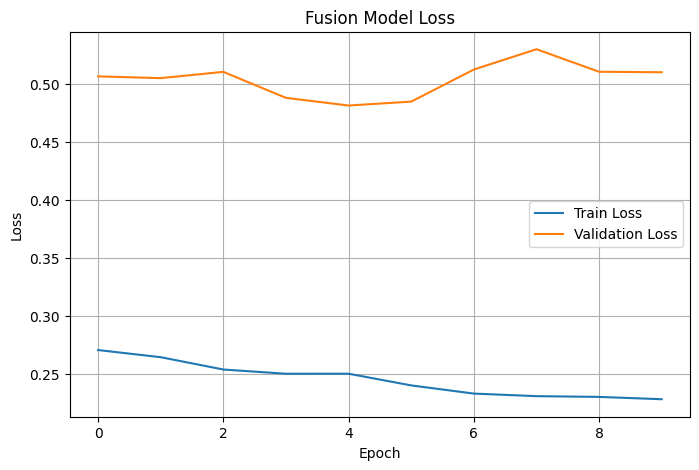

🎉 Training Finished!


3

In [17]:
# --- SNIPPET 4: Fusion Training Loop ---

import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(fusion_model.parameters(), lr=2e-4, weight_decay=1e-4)
scaler = GradScaler()

num_epochs = 10

train_losses = []
val_losses = []
train_accs = []
val_accs = []

def evaluate(model, loader):
    model.eval()
    total = 0
    correct = 0
    loss_sum = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            loss = criterion(out, labels)

            preds = out.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            loss_sum += loss.item()

    return (correct/total)*100, loss_sum / len(loader)

best_val_loss = float("inf")

for epoch in range(num_epochs):
    fusion_model.train()
    running_loss = 0
    correct = 0
    total = 0

    for imgs, labels in tqdm(train_loader):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()

        with autocast():
            out = fusion_model(imgs)
            loss = criterion(out, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        preds = out.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc  = (correct / total) * 100

    val_acc, val_loss = evaluate(fusion_model, test_loader)

    train_losses.append(epoch_train_loss)
    val_losses.append(val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(val_acc)

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(fusion_model.state_dict(),
                   "/content/drive/MyDrive/morph_project/models/fusion_best.pth")
        print("🔥 Saved best fusion model!")

# ---- Plot Accuracy ----
plt.figure(figsize=(8,5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Fusion Model Accuracy")
plt.legend()
plt.grid()
plt.show()

# ---- Plot Loss ----
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fusion Model Loss")
plt.legend()
plt.grid()
plt.show()

print("🎉 Training Finished!")
3

In [19]:
!find "/content/drive" -type f -name "*.pth"


/content/drive/MyDrive/morph_project/models/vit_casia.pth
/content/drive/MyDrive/morph_project/models/vit_hdf5.pth
/content/drive/MyDrive/morph_project/models/fusion_best.pth
/content/drive/MyDrive/morph_project/efficientnet_b3_casia.pth


Device: cuda

=== TEST ACCURACY ===
EfficientNet B3 (CASIA): 44.54%
ViT (HDF5):             82.70%
Fusion Model:           83.31%


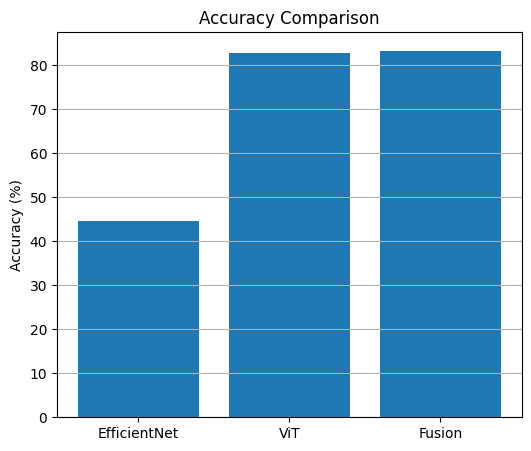

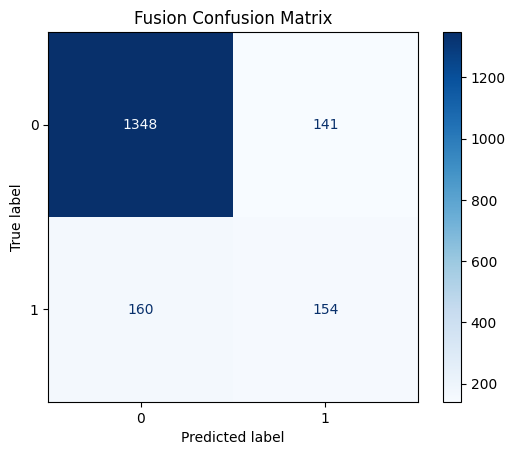

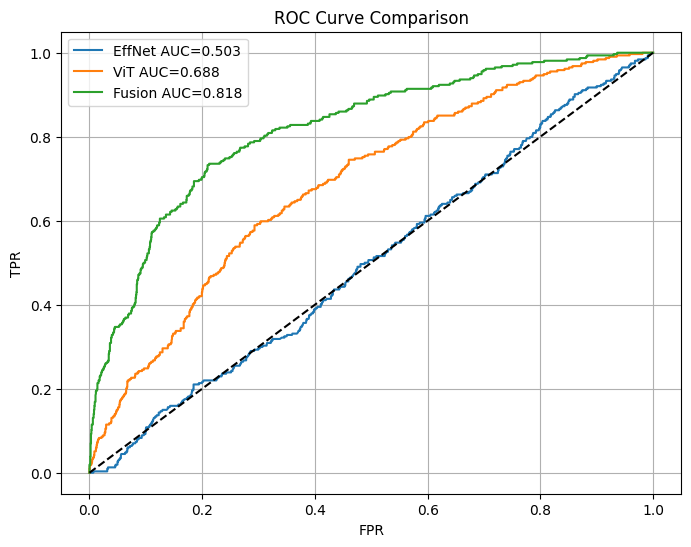

In [20]:
# --- SNIPPET 5: FINAL COMPARISON (EfficientNet vs ViT vs Fusion) ---

import torch
import torch.nn as nn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import timm

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

############################################################
# 1) LOAD ALL THREE MODELS
############################################################

# EfficientNet Model (CASIA trained)
eff_model = timm.create_model("tf_efficientnet_b3_ns", pretrained=False, num_classes=2)
eff_model.load_state_dict(torch.load("/content/drive/MyDrive/morph_project/efficientnet_b3_casia.pth", map_location=device))
eff_model = eff_model.to(device)
eff_model.eval()

# ViT Model (HDF5 trained)
vit_model = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=2)
vit_model.load_state_dict(torch.load("/content/drive/MyDrive/morph_project/models/vit_hdf5.pth", map_location=device))
vit_model = vit_model.to(device)
vit_model.eval()

# Fusion Model
fusion_model = FusionModel(
    eff_model=EfficientNetBackbone(model_name="tf_efficientnet_b3_ns", pretrained=False, emb_dim=512),
    vit_model=ViTBackbone(model_name="vit_base_patch16_224", pretrained=False, emb_dim=512),
    emb_dim=512,
    num_classes=2
)
fusion_model.load_state_dict(torch.load("/content/drive/MyDrive/morph_project/models/fusion_best.pth", map_location=device))
fusion_model = fusion_model.to(device)
fusion_model.eval()


############################################################
# 2) Evaluation Function
############################################################

def get_predictions(model, loader):
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            out = model(imgs)
            probs = torch.softmax(out, dim=1)[:, 1]

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


############################################################
# 3) Compute Results
############################################################

labels_eff, preds_eff, probs_eff = get_predictions(eff_model, test_loader)
labels_vit, preds_vit, probs_vit = get_predictions(vit_model, test_loader)
labels_fus, preds_fus, probs_fus = get_predictions(fusion_model, test_loader)


############################################################
# 4) Print Accuracy
############################################################

acc_eff = (preds_eff == labels_eff).mean() * 100
acc_vit = (preds_vit == labels_vit).mean() * 100
acc_fus = (preds_fus == labels_fus).mean() * 100

print("\n=== TEST ACCURACY ===")
print(f"EfficientNet B3 (CASIA): {acc_eff:.2f}%")
print(f"ViT (HDF5):             {acc_vit:.2f}%")
print(f"Fusion Model:           {acc_fus:.2f}%")


############################################################
# 5) Accuracy Comparison Bar Chart
############################################################

plt.figure(figsize=(6,5))
plt.bar(["EfficientNet", "ViT", "Fusion"], [acc_eff, acc_vit, acc_fus])
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison")
plt.grid(True, axis='y')
plt.show()


############################################################
# 6) Confusion Matrix (Fusion)
############################################################

cm = confusion_matrix(labels_fus, preds_fus)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Fusion Confusion Matrix")
plt.show()


############################################################
# 7) ROC Comparison
############################################################

fpr_eff, tpr_eff, _ = roc_curve(labels_eff, probs_eff)
fpr_vit, tpr_vit, _ = roc_curve(labels_vit, probs_vit)
fpr_fus, tpr_fus, _ = roc_curve(labels_fus, probs_fus)

auc_eff = auc(fpr_eff, tpr_eff)
auc_vit = auc(fpr_vit, tpr_vit)
auc_fus = auc(fpr_fus, tpr_fus)

plt.figure(figsize=(8,6))
plt.plot(fpr_eff, tpr_eff, label=f"EffNet AUC={auc_eff:.3f}")
plt.plot(fpr_vit, tpr_vit, label=f"ViT AUC={auc_vit:.3f}")
plt.plot(fpr_fus, tpr_fus, label=f"Fusion AUC={auc_fus:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()


In [27]:
# --- SNIPPET 6: Predict User Image Using Fusion Model ---

import cv2
import torch
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load fusion model
fusion_model = FusionModel(
    eff_model=EfficientNetBackbone(model_name="tf_efficientnet_b3_ns", pretrained=False, emb_dim=512),
    vit_model=ViTBackbone(model_name="vit_base_patch16_224", pretrained=False, emb_dim=512),
    emb_dim=512,
    num_classes=2
)
fusion_model.load_state_dict(torch.load("/content/drive/MyDrive/morph_project/models/fusion_best.pth", map_location=device))
fusion_model = fusion_model.to(device)
fusion_model.eval()

# The SAME mean/std used during HDF5 creation
DATA_MEAN = 0.5000274186210306
DATA_STD  = 0.33424043291017097

def preprocess_user_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224,224))

    img = img.astype(np.float32)
    img = (img - DATA_MEAN) / (DATA_STD + 1e-7)

    img = torch.tensor(img).permute(2,0,1).unsqueeze(0).float().to(device)
    return img

def predict_image(path):
    img = preprocess_user_image(path)

    with torch.no_grad():
        out = fusion_model(img)
        probs = torch.softmax(out, dim=1)[0]
        pred = probs.argmax().item()

    label = "Au (Authentic)" if pred == 0 else "Tp (Tampered)"
    confidence = float(probs[pred] * 100)

    print("\n🖼 IMAGE:", path)
    print("Prediction:", label)
    print(f"Confidence: {confidence:.2f}%")

# Upload image
from google.colab import files
uploaded = files.upload()

for name in uploaded.keys():
    predict_image(name)


Saving cpymv1.png to cpymv1 (1).png

🖼 IMAGE: cpymv1 (1).png
Prediction: Au (Authentic)
Confidence: 100.00%


In [28]:
torch.save(fusion_model.state_dict(),
           "/content/drive/MyDrive/morph_project/models/fusion_final.pth")
print("Fusion Model Saved Permanently!")


Fusion Model Saved Permanently!


In [31]:
# =====================================================================
# FINAL — WORKING — STANDALONE FUSION INFERENCE SCRIPT (MATCHES TRAINING)
# =====================================================================

import torch
import torch.nn as nn
import timm
import cv2
import numpy as np
from google.colab import files

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ---------------------------------------------------------------------
# 1. INSERT YOUR REAL MEAN AND STD HERE
# ---------------------------------------------------------------------
DATA_MEAN = 0.5000274186210306          # float
DATA_STD  = 0.33424043291017097


# ---------------------------------------------------------------------
# 2. BACKBONES — EXACT SAME AS TRAINING (uses self.net)
# ---------------------------------------------------------------------

class EfficientNetBackbone(nn.Module):
    def __init__(self, model_name="tf_efficientnet_b3_ns", pretrained=False, emb_dim=512):
        super().__init__()

        # EXACT same as training
        self.net = timm.create_model(
            model_name, pretrained=pretrained, num_classes=0, global_pool='avg'
        )
        in_features = self.net.num_features

        self.proj = nn.Sequential(
            nn.Linear(in_features, emb_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

    def forward(self, x):
        feats = self.net(x)
        if feats.ndim == 4:
            feats = feats.mean([2, 3])
        return self.proj(feats)


class ViTBackbone(nn.Module):
    def __init__(self, model_name="vit_base_patch16_224", pretrained=False, emb_dim=512):
        super().__init__()

        self.net = timm.create_model(
            model_name, pretrained=pretrained, num_classes=0, global_pool='avg'
        )
        in_features = self.net.num_features

        self.proj = nn.Sequential(
            nn.Linear(in_features, emb_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

    def forward(self, x):
        feats = self.net(x)
        return self.proj(feats)


# ---------------------------------------------------------------------
# 3. FUSION MODEL — EXACT ARCHITECTURE FROM TRAINING
# ---------------------------------------------------------------------

class FusionModel(nn.Module):
    def __init__(self, emb_dim=512, num_classes=2):
        super().__init__()
        self.eff = EfficientNetBackbone(pretrained=False, emb_dim=emb_dim)
        self.vit = ViTBackbone(pretrained=False, emb_dim=emb_dim)

        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 2, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        eff_out = self.eff(x)
        vit_out = self.vit(x)
        fused = torch.cat([eff_out, vit_out], dim=1)
        return self.classifier(fused)


# ---------------------------------------------------------------------
# 4. LOAD TRAINED FUSION WEIGHTS (NOW WILL WORK 100%)
# ---------------------------------------------------------------------

fusion_model = FusionModel().to(device)
fusion_model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/morph_project/models/fusion_best.pth",
        map_location=device
    ),
    strict=True
)
fusion_model.eval()

print("\n🔥 Fusion model loaded successfully!\n")


# ---------------------------------------------------------------------
# 5. IMAGE PREPROCESSING — SAME AS HDF5
# ---------------------------------------------------------------------

def preprocess_user_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224,224))
    img = img.astype(np.float32)

    # SAME normalization used in your HDF5 pipeline
    img = (img - DATA_MEAN) / (DATA_STD + 1e-7)

    img = torch.tensor(img).permute(2,0,1).unsqueeze(0).to(device)
    return img


# ---------------------------------------------------------------------
# 6. PREDICTION FUNCTION
# ---------------------------------------------------------------------

def predict_image(path):
    img = preprocess_user_image(path)
    with torch.no_grad():
        out = fusion_model(img)
        probs = torch.softmax(out, dim=1)[0]
        pred = probs.argmax().item()

    label = "AU (Authentic)" if pred == 0 else "TP (Tampered)"
    conf = float(probs[pred] * 100)

    print("====================================")
    print("Image:", path)
    print("Prediction:", label)
    print(f"Confidence: {conf:.2f}%")
    print("====================================\n")


# ---------------------------------------------------------------------
# 7. USER INPUT
# ---------------------------------------------------------------------

uploaded = files.upload()
for name in uploaded.keys():
    predict_image(name)


Device: cuda

🔥 Fusion model loaded successfully!



Saving img0.1.png to img0.1 (1).png
Image: img0.1 (1).png
Prediction: AU (Authentic)
Confidence: 100.00%



In [32]:
import h5py
import numpy as np

h5 = h5py.File("/content/drive/MyDrive/morph_project/processed/train.h5", "r")
y = np.array(h5["y"])

print("Unique labels in train:", np.unique(y, return_counts=True))


Unique labels in train: (array([0, 1], dtype=int32), array([5946, 1231]))


In [34]:
import h5py
import numpy as np

h5_test = h5py.File("/content/drive/MyDrive/morph_project/processed/test.h5", "r")
y_test = np.array(h5_test["y"])

print("Test distribution:", np.unique(y_test, return_counts=True))


Test distribution: (array([0, 1], dtype=int32), array([1489,  314]))


In [36]:
import h5py
import numpy as np
import torch

# Load train labels
h5 = h5py.File("/content/drive/MyDrive/morph_project/processed/train.h5", "r")
y_train = np.array(h5["y"])

# Count AU and TP
count_au = np.sum(y_train == 0)
count_tp = np.sum(y_train == 1)

total_samples = len(y_train)

print("AU count (0):", count_au)
print("TP count (1):", count_tp)
print("Total samples:", total_samples)

# Compute class weights
weight_for_au = total_samples / (2 * count_au)
weight_for_tp = total_samples / (2 * count_tp)

print("\nWeight for AU (0):", weight_for_au)
print("Weight for TP (1):", weight_for_tp)

# Tensor for PyTorch
class_weights = torch.tensor([weight_for_au, weight_for_tp], dtype=torch.float32).cuda()

print("\nClass Weights Tensor:", class_weights)


AU count (0): 5946
TP count (1): 1231
Total samples: 7177

Weight for AU (0): 0.603514968045745
Weight for TP (1): 2.9151096669374494

Class Weights Tensor: tensor([0.6035, 2.9151], device='cuda:0')


In [37]:
preds = []
fusion_model.eval()

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        out = fusion_model(imgs)
        preds.extend(out.argmax(1).cpu().numpy())

print("Pred distribution:", np.unique(preds, return_counts=True))


Pred distribution: (array([0, 1]), array([1508,  295]))


In [38]:
import h5py
import numpy as np

h5 = h5py.File("/content/drive/MyDrive/morph_project/processed/train.h5", "r")
X = np.array(h5["X"])

DATA_MEAN = X.mean()
DATA_STD = X.std()

print("DATA_MEAN =", DATA_MEAN)
print("DATA_STD =", DATA_STD)


DATA_MEAN = -2.6647588e-06
DATA_STD = 0.9996273
